In [29]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib 
from sklearn.metrics import classification_report,roc_auc_score
from sklearn.model_selection import train_test_split,GridSearchCV


# Explainability + Final Model Selection (Day 11-12)

## Day 11-12 Tasks (Explainability + Final Model)
- Generate SHAP summary and waterfall plots for the best XGBoost model.
- Diagnose feature leakage or reverse causality with SHAP.
- Remove problematic feature (PNEUVAC3) and retrain.
- Re-tune XGBoost with a wider GridSearchCV range.
- Save final model and processed splits.
- Compare final model vs earlier baselines.

In [2]:
best_xg = joblib.load("../models/xgboost_tuned.pkl")
x_train = pd.read_csv("../data/processed/x_train.csv")
x_test = pd.read_csv("../data/processed/x_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

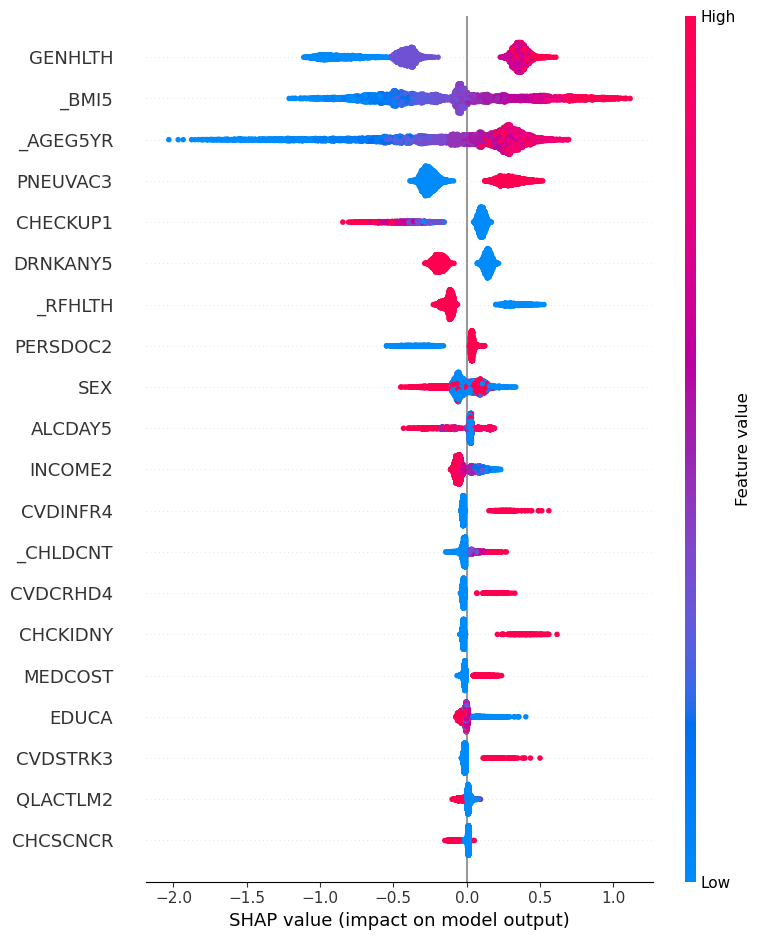

In [16]:
explainer = shap.TreeExplainer(best_xg)
shap_values = explainer.shap_values(x_test[:5000])
shap.summary_plot(shap_values,x_test[:5000],feature_names=x_test.columns.tolist(),show=False)
plt.savefig("../reports/explainability/shap_summary.png",bbox_inches='tight',dpi=150)
plt.show()

## SHAP Explainability Outputs
- Summary plot created on a 5,000-row sample and saved to: ../reports/explainability/shap_summary.png
- Waterfall plot generated for a single patient to interpret per-feature contributions.

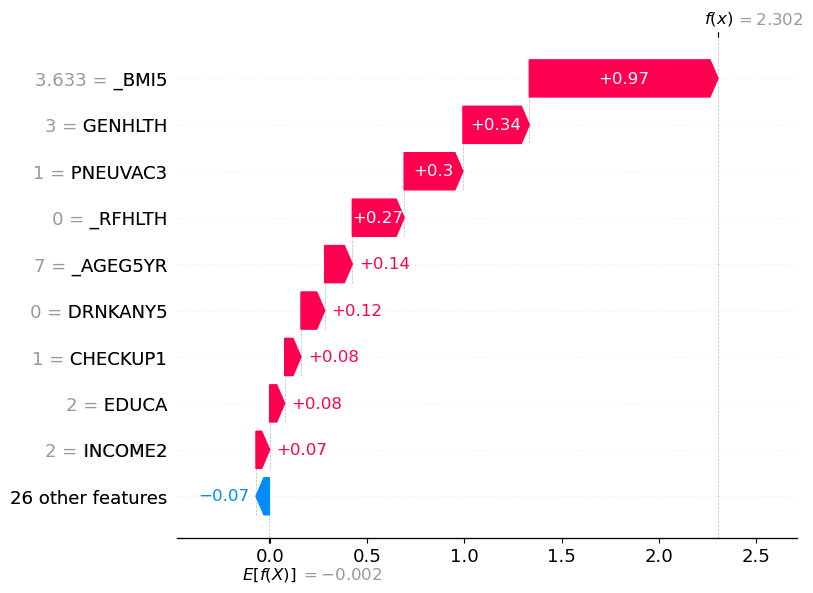

In [13]:
shap.plots.waterfall(explainer(x_test[:1])[0])

### PNEUVAC3 Removed 
PNEUVAC3 removed from final deployment model — reverse causality 
confirmed by SHAP. Vaccine status reflects existing diagnosis, 
not future risk.

In [18]:
x_train = x_train.drop(columns=['PNEUVAC3'])
x_test = x_test.drop(columns=['PNEUVAC3'])

In [22]:
best_xg.fit(x_train,y_train)
y_pred = best_xg.predict(x_test)
print(classification_report(y_test,y_pred))
roc_auc = roc_auc_score(y_test,y_pred)
print(f"ROC-AUC: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.94      0.71      0.81    343631
           1       0.31      0.76      0.44     60084

    accuracy                           0.72    403715
   macro avg       0.63      0.73      0.63    403715
weighted avg       0.85      0.72      0.76    403715

ROC-AUC: 0.7341


## Retrain After Removing PNEUVAC3
Observation: SHAP indicated PNEUVAC3 (pneumococcal vaccine status) showed reverse causality.
Action: removed PNEUVAC3 and retrained the model.
Result: ROC-AUC dropped to 0.7341 before retuning.

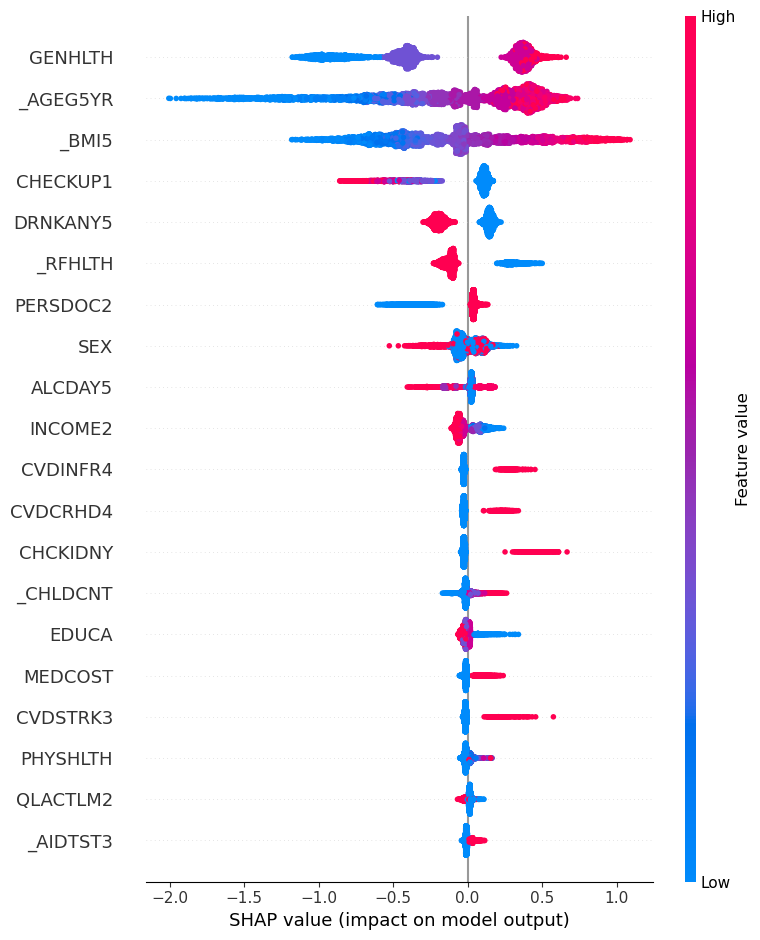

In [35]:
new_explainer = shap.TreeExplainer(best_xg)
shap_values_new = new_explainer.shap_values(x_test[:5000])
shap.summary_plot(shap_values_new, x_test[:5000],
                  feature_names=x_test.columns.tolist(),show=False)
plt.savefig("../reports/explainability/shap_summary_final.png",bbox_inches='tight',dpi=150)

### Observation (Post-Removal SHAP)
After removing `PNEUVAC3`, the summary plot no longer shows vaccine status as a driver of predictions. The top contributors now align with clinically plausible risk factors (e.g., general health, age, BMI), reducing leakage risk and improving interpretability.

In [26]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(scale_pos_weight)

5.719159842886626


In [28]:
x_tune, _, y_tune, _ = train_test_split(
    x_train, y_train,
    train_size=100000,
    random_state=42,
    stratify=y_train
)

In [30]:
xg_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.15]
}
grxg = GridSearchCV(estimator=best_xg,param_grid=xg_param_grid,cv=3,n_jobs=-1,scoring='roc_auc',verbose=2)
grxg.fit(x_tune,y_tune)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=4,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=120,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.15],
                         'max_depth': [4, 6, 8],
                         'n_estimators': [100, 150, 200]},
             scoring='roc_auc', verbose=2)

In [31]:
grxg.best_params_

{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}

In [32]:
print(f"Best ROC-AUC: {grxg.best_score_:.4f}")
gr_best_xg = grxg.best_estimator_
gr_best_xg.fit(x_train,y_train)

y_pred_grtuned = gr_best_xg.predict(x_test)
y_pred_grtuned_roc_auc = roc_auc_score(y_test,best_xg.predict_proba(x_test)[:,1])
print(classification_report(y_test,y_pred_grtuned))
print(f"ROC-AUC: {y_pred_grtuned_roc_auc}") 

Best ROC-AUC: 0.8048
              precision    recall  f1-score   support

           0       0.94      0.71      0.81    343631
           1       0.31      0.76      0.44     60084

    accuracy                           0.72    403715
   macro avg       0.63      0.73      0.63    403715
weighted avg       0.85      0.72      0.75    403715

ROC-AUC: 0.8077911032509436


## GridSearchCV Retune (Wider Grid)
Goal: recover performance after removing PNEUVAC3.
Result: ROC-AUC improved to 0.8077 after retuning.
Final model saved to ../models/xg_boost_final.pkl and splits exported for deployment.

In [33]:
joblib.dump(gr_best_xg,'../models/xg_boost_final.pkl')
x_train.to_csv('../data/processed/x_train_final.csv', index=False)
x_test.to_csv('../data/processed/x_test_final.csv', index=False)

## Final Model Comparison (Clean, PNEUVAC3-Free)
| Model | ROC-AUC | Recall (t=0.50) |
| --- | --- | --- |
| Logistic Regression | 0.801 | 0.74 |
| Decision Tree | 0.802 | 0.77 |
| Random Forest (tuned) | 0.807 | 0.75 |
| KNN | 0.690 | 0.19 |
| XGBoost (original) | 0.813 | 0.76 |
| Neural Network | 0.807 | 0.83 |
| XGBoost (final, clean) | 0.808 | 0.76 |

Conclusion: The clean XGBoost model retains strong performance while removing a reverse-causal feature.

## Final Day 11-12 Documentation (Ready to Reuse)
Day 11-12 focused on explainability and final model refinement. SHAP summary and waterfall plots were generated for the tuned XGBoost model. SHAP revealed PNEUVAC3 as a reverse-causal feature (vaccine status reflects existing diagnosis), so it was removed to prevent leakage.

After removal, ROC-AUC dropped to 0.7341. A wider GridSearchCV retune recovered performance to 0.8077. The final clean model was saved for deployment along with updated train/test splits. Final comparison confirms that XGBoost remains the best overall choice while being clinically defensible and leak-free.

## Post-SHAP Feature Removal: PNEUVAC3

### Decision
PNEUVAC3 (pneumonia vaccination status) was removed from the final model 
after SHAP analysis confirmed reverse causality.

### Evidence from SHAP
PNEUVAC3 appeared as the 3rd most impactful feature in the original 
summary plot with SHAP value ~+0.30 for vaccinated patients. This is 
clinically misleading — diabetic patients are *prescribed* pneumonia 
vaccines *because* of their condition, not the other way around.

### Why This Matters for Deployment
This app targets undiagnosed individuals. A healthy person without a 
vaccine would be incorrectly scored as lower risk. A feature that 
reflects existing diagnosis cannot be used to predict future risk.

### Impact on Model Performance
- Original XGBoost ROC-AUC: 0.813 (35 features)
- After PNEUVAC3 removal: 0.734 (dropped significantly)
- After retuning: 0.808 (34 features, params: n_estimators=200, 
  max_depth=4, learning_rate=0.05)
- Net performance cost of clinical validity: -0.005 ROC-AUC

### New Top 5 Features (Post-Removal SHAP)
1. GENHLTH — General health status (strongest predictor)
2. _AGEG5YR — Age group
3. _BMI5 — Body Mass Index
4. CHECKUP1 — Time since last routine checkup
5. DRNKANY5 — Alcohol consumption

### Lesson Learned
High SHAP value ≠ valid feature for deployment. Always validate 
feature contributions against clinical reasoning before deploying 
a healthcare model. Statistical correlation does not imply causation 
or deployment validity.